<a href="https://colab.research.google.com/github/ese-ada-lovelace-2025/irp-wm722/blob/main/FPNCentreNet.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# @title
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
from sklearn.metrics import accuracy_score, r2_score
from pathlib import Path
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader, Dataset
import torchvision.datasets
import torchvision.transforms as transforms
from torch.utils.data import WeightedRandomSampler
import random
import glob
from scipy.ndimage import gaussian_filter, zoom

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# @title
def set_seed(seed):
    """
    Use this to set ALL the random seeds to a fixed value and take out any randomness from cuda kernels
    """
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.benchmark = False  ##uses the inbuilt cudnn auto-tuner to find the fastest convolution algorithms. -
    torch.backends.cudnn.enabled = False

    return True

device = 'cpu'
if torch.cuda.device_count() > 0 and torch.cuda.is_available():
    print("Cuda installed! Running on GPU!")
    device = 'cuda'
else:
    print("No GPU available!")

set_seed(42)

Cuda installed! Running on GPU!


True

In [ ]:
import sys
sys.path.append('/content/drive/MyDrive/IRP/scripts')
from sklearn.model_selection import train_test_split

from FPNCentreNet import FPNCentreNet, CentreNetLoss, MultiLevelCentreNetDataset, FPN_CN_train, decode_multilevel_predictions


In [ ]:
paths = glob.glob('/content/drive/MyDrive/IRP/Tiles/ScalesCombined/*/*.npz')
paths.extend(glob.glob('/content/drive/MyDrive/IRP/Tiles/Negatives/*/*.npz')[::6])
paths.extend(glob.glob('/content/drive/MyDrive/IRP/Tiles/UKNegatives/*/*.npz'))[::4]
train_paths, val_paths = train_test_split(paths, test_size=0.2)

In [ ]:
train_ds = MultiLevelCentreNetDataset(
    train_paths,
    augment=True,
)

val_ds = MultiLevelCentreNetDataset(
    val_paths,
    augment=False,
)

train_loader = DataLoader(
    train_ds,
    batch_size=4,
    shuffle=True,
    num_workers=2,
    pin_memory=True,
)

val_loader = DataLoader(
    val_ds,
    batch_size=4,
    shuffle=False,
    num_workers=2,
    pin_memory=True,
)

Found 270 tiles (0 partial, 0 missing bands skipped)
Found 68 tiles (0 partial, 0 missing bands skipped)


In [ ]:
model = FPNCentreNet(train_all = False)

criterion = CentreNetLoss(
    alpha=2.0,
    beta=4.0,
    off_weight=0.2,
    rad_weight=0.1,
    neg_scale=1.0,
)

In [ ]:
vls, tls, precisions, recalls, f1s, model, val_loader = FPN_CN_train(
    model=model,
    criterion=criterion,
    train_loader=train_loader,
    val_loader=val_loader,
    epochs=50)

Applied training stage 1
  heads    lr=1.00e-03, trainable=7,088,144
  conv1    lr=5.00e-06, trainable=15,680
  pan      lr=1.00e-03, trainable=4,132,352
  fpn      lr=0.00e+00, trainable=0
  layer4   lr=0.00e+00, trainable=0
  layer3   lr=0.00e+00, trainable=0
Best checkpoint saved: F1=0.0000
Epoch   1/50 | train 2.8770 | val 2.1012 | P 0.0000 | R 0.0000 | F1 0.0000
Best checkpoint saved: F1=0.0870
Epoch   2/50 | train 2.1361 | val 1.6455 | P 1.0000 | R 0.0455 | F1 0.0870
Epoch   3/50 | train 1.9009 | val 1.6932 | P 0.0000 | R 0.0000 | F1 0.0000
Best checkpoint saved: F1=0.1197
Epoch   4/50 | train 1.7983 | val 1.5689 | P 1.0000 | R 0.0636 | F1 0.1197
Epoch   5/50 | train 1.5062 | val 0.9240 | P 1.0000 | R 0.0591 | F1 0.1116
Best checkpoint saved: F1=0.4950
Epoch   6/50 | train 1.1169 | val 0.8034 | P 0.9367 | R 0.3364 | F1 0.4950
Epoch   7/50 | train 1.0677 | val 0.9034 | P 0.8000 | R 0.0727 | F1 0.1333
Best checkpoint saved: F1=0.5419
Epoch   8/50 | train 1.0727 | val 0.8587 | P 0.9

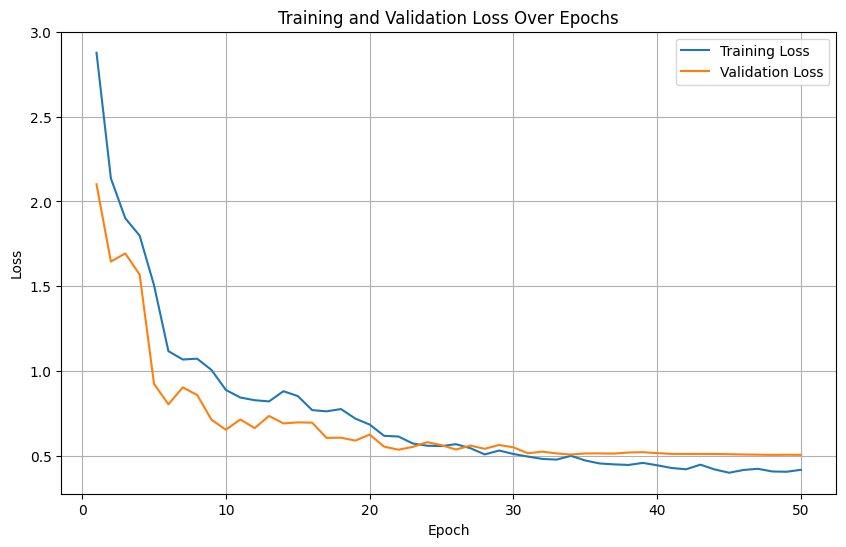

In [ ]:
epochs_run = len(tls)
epochs_list = range(1, epochs_run + 1)

plt.figure(figsize=(10, 6))
plt.plot(epochs_list, tls, label='Training Loss')
plt.plot(epochs_list, vls, label='Validation Loss')
plt.title('Training and Validation Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

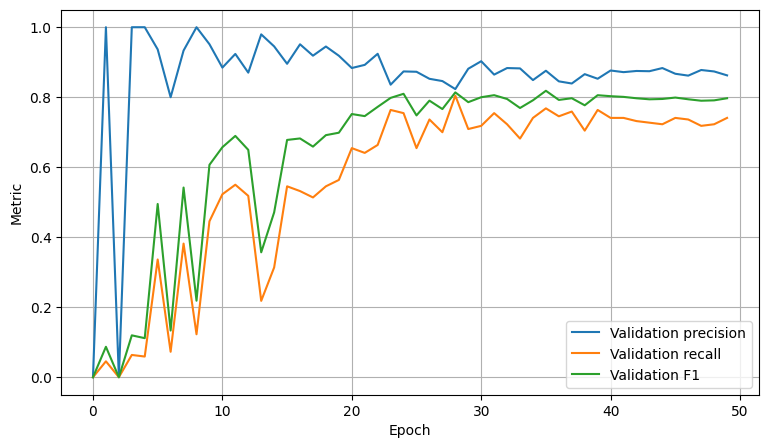

In [ ]:
plt.figure(figsize=(9, 5))
plt.plot(precisions, label="Validation precision")
plt.plot(recalls, label="Validation recall")
plt.plot(f1s, label="Validation F1")
plt.xlabel("Epoch")
plt.ylabel("Metric")
plt.legend()
plt.grid(True)
plt.show()

Testing FPN layer set-up